In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Определяем заданные параметры

g = 9.81
dt = 0.02               # маленький временной интервал для калибровки ДУС
window_size = 50        # размер скользящего окна 
var_threshold_gyro = 2  # порог чувствительности

In [21]:
# Подготовительные работы

columns = ['ID', 'MAG1', 'MAG2', 'MAG3', 'ACS1', 'ACS2', 'AKS3', 'GYRO1', 'GYRO2', 'GYRO3', 'HH', 'MM', 'SS', 'MS']
df = pd.read_csv('INS-MEMS2.LOG', sep=r'\s+', engine='python', header=None, comment='%')
df.columns = columns
df = df.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

# Гироскопические данные 
GYRO = df[['GYRO1', 'GYRO2', 'GYRO3']].to_numpy()
si = GYRO.shape[0]                                   # количество строк в этом массиве, то есть общее количество временных точек, для которых есть данные о гироскопе

In [22]:
# Определение покоя

stationary = np.zeros(si, dtype=bool)  # true - покой, false - движение 

for i in range(si - window_size + 1):  # запускаем скользящее окно по всем данным. Например, если window_size = 50, то мы берём подряд 50 точек и двигаем окно от начала до конца данных.
    gyro_window = GYRO[i:i+window_size, :]  # берём подмассив по трём осям
    var_gyro = np.var(gyro_window, axis=0)  # Вычисляется дисперсия угловых скоростей по каждой оси в этом окне. axis=0 — означает, что дисперсия считается по времени (по строкам), отдельно для каждой из осей.
    # Если дисперсия на всех трёх осях меньше заданного порога, считаем, что устройство покоится.
    if np.all(var_gyro < var_threshold_gyro) or np.sum(var_gyro > var_threshold_gyro) >= 2:
        stationary[i:i+window_size] = True

In [23]:
# Разделение на интервалы

stationary_intervals = []
motion_intervals = []
start = 0

for i in range(1, si):
    if stationary[i-1] and not stationary[i]:
        stationary_intervals.append([start, i-1])
        start = i
    elif not stationary[i-1] and stationary[i]:
        motion_intervals.append([start, i-1])
        start = i

if start < si:
    if stationary[-1]:
        stationary_intervals.append([start, si-1])
    else:
        motion_intervals.append([start, si-1])

In [24]:
# Калибровка ДУС
if len(stationary_intervals) == 0 or len(motion_intervals) < 2:
    raise ValueError("Недостаточно интервалов движения или покоя для калибровки.")

first_stationary = stationary_intervals[0]
idx = slice(first_stationary[0], first_stationary[1] + 1)

delta_t0 = (first_stationary[1] - first_stationary[0] + 1) * dt
phi_prime_0 = np.array([np.trapz(GYRO[idx, axis]) * dt for axis in range(3)])
tilde_b_w = phi_prime_0 / delta_t0

C:\Users\arefe\AppData\Local\Temp\ipykernel_23772\2918560893.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  phi_prime_0 = np.array([np.trapz(GYRO[idx, axis]) * dt for axis in range(3)])


In [ ]:
# Расчёт поправок
required_intervals = min(6, len(motion_intervals))
delta_phi_prime = np.zeros((required_intervals, 3))
for i in range(required_intervals):
    idx = slice(motion_intervals[i][0], motion_intervals[i][1] + 1)
    for axis in range(3):
        delta_phi_prime[i, axis] = np.trapz(GYRO[idx, axis] - tilde_b_w[axis]) * dt

C:\Users\arefe\AppData\Local\Temp\ipykernel_23772\816237148.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  delta_phi_prime[i, axis] = np.trapz(GYRO[idx, axis] - tilde_b_w[axis]) * dt


In [26]:
# Калибровочная матрица
S_ww = np.zeros((required_intervals // 2, 3))
for j in range(required_intervals // 2):
    S_ww[j, :] = delta_phi_prime[2*j, :] - delta_phi_prime[2*j + 1, :]
S_ww /= 360

S_omega = np.linalg.pinv(S_ww)  # псевдообратная
b_w = -S_omega @ tilde_b_w

In [27]:
# Коррекция гироданных
GYRO_t = GYRO.T
b_w_2 = b_w[:, np.newaxis] * np.ones(GYRO_t.shape[1])
w_z = (S_omega @ GYRO_t + b_w_2).T

# Интегралы 
integrals = np.zeros((required_intervals, 3))
for i in range(required_intervals):
    start_idx, end_idx = motion_intervals[i]
    for axis in range(3):
        integrals[i, axis] = np.trapz(w_z[start_idx:end_idx+1, axis]) * dt

C:\Users\arefe\AppData\Local\Temp\ipykernel_23772\1138143734.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integrals[i, axis] = np.trapz(w_z[start_idx:end_idx+1, axis]) * dt


In [28]:
# Вывод результатов
print("Результаты по угловым скоростям на интервалах движения:\n")
for i in range(required_intervals):
    print(f"Интервал {i+1} (индексы {motion_intervals[i][0]}:{motion_intervals[i][1]}):")
    print(f"\tx: {integrals[i, 0]:.4f} град.")
    print(f"\ty: {integrals[i, 1]:.4f} град.")
    print(f"\tz: {integrals[i, 2]:.4f} град.\n")

Результаты по угловым скоростям на интервалах движения:

Интервал 1 (индексы 786:942):
	x: 183.3212 град.
	y: -1.0490 град.
	z: -4.7009 град.

Интервал 2 (индексы 1676:1760):
	x: -176.6988 град.
	y: -1.1180 град.
	z: -1.9323 град.

Интервал 3 (индексы 2515:2607):
	x: 2.2267 град.
	y: 180.9318 град.
	z: -6.0123 град.

Интервал 4 (индексы 3081:3178):
	x: 2.0831 град.
	y: -179.0177 град.
	z: 2.4498 град.

Интервал 5 (индексы 3553:3643):
	x: 0.2032 град.
	y: 5.2989 град.
	z: 242.9647 град.

Интервал 6 (индексы 3786:3823):
	x: 2.2003 град.
	y: -1.0384 град.
	z: -116.9323 град.



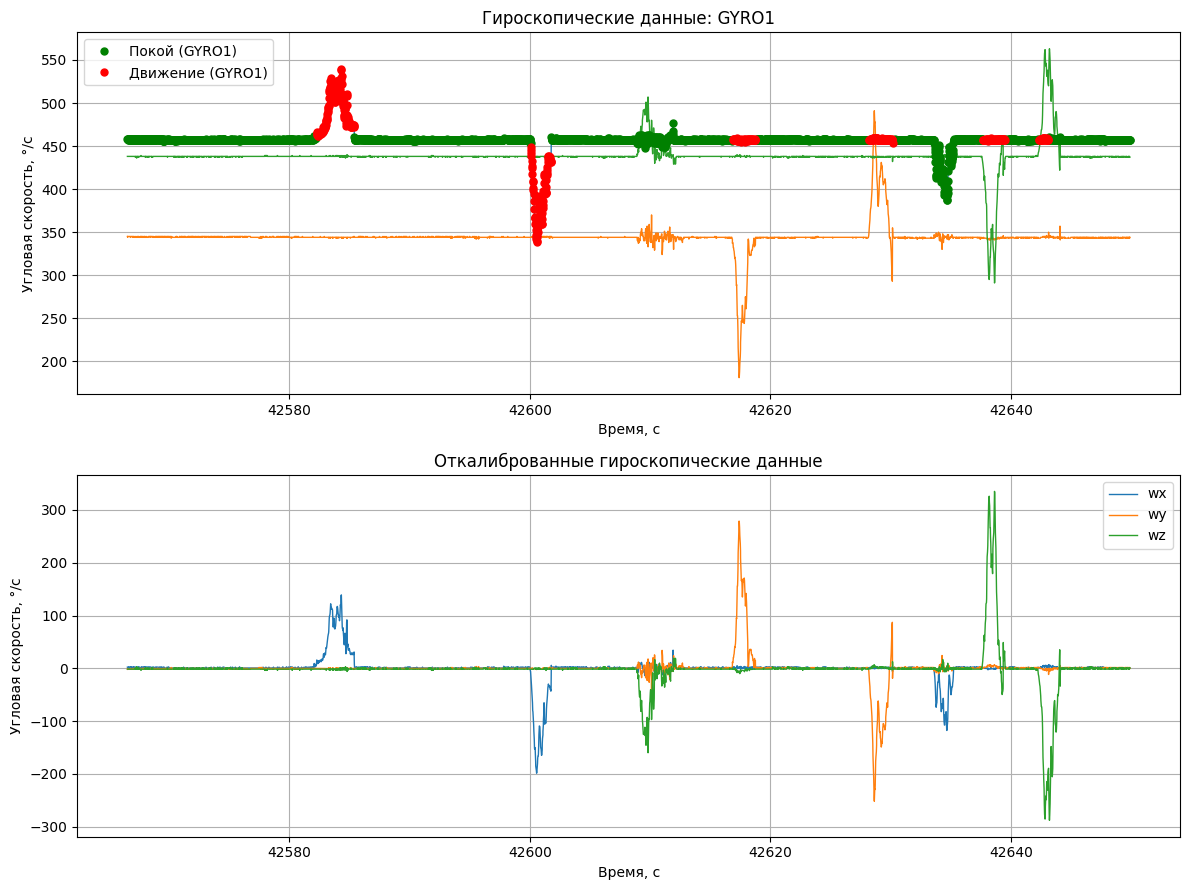

In [29]:
# Визуализация

time = df['HH']*3600 + df['MM']*60 + df['SS'] + df['MS']/1000

plt.figure(figsize=(12, 9))

plt.subplot(2, 1, 1)
plt.plot(time, GYRO, linewidth=1)
stationary_idx = np.where(stationary)[0]
motion_idx = np.where(~stationary)[0]
if stationary_idx.size > 0:
    plt.plot(time[stationary_idx], GYRO[stationary_idx, 0], 'g.', label='Покой (GYRO1)', markersize=10)
if motion_idx.size > 0:
    plt.plot(time[motion_idx], GYRO[motion_idx, 0], 'r.', label='Движение (GYRO1)', markersize=10)

plt.title('Гироскопические данные: GYRO1')
plt.xlabel('Время, с')
plt.ylabel('Угловая скорость, °/с')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time, w_z, linewidth=1)
plt.title('Откалиброванные гироскопические данные')
plt.xlabel('Время, с')
plt.ylabel('Угловая скорость, °/с')
plt.legend(['wx', 'wy', 'wz'])
plt.grid()

plt.tight_layout()
plt.savefig("gyro_calibration_plot.png")
plt.show()


In [30]:
output_data = np.column_stack([time, GYRO, stationary.astype(int)])
np.savetxt("stationary_motion_gyro.txt", output_data, delimiter="\t", fmt="%.6f")